- In this notebook, you will learn how to load scintillation, TEC and ROT data sampled at 50 Hz by a GNSS receiver located in Svalbard, Norway (high latitude station).
<br>

- Data is available to download from: https://dataverse.no/dataverse/gnss (make sure to cite the source).
<br>

- We will then make time series plots of $S_4$, $\sigma_\phi$, VTEC and ROT, and interpret the results.
<br>

- If you do not have any of the necessary (below) modules/libraries, you can install them using <font color="red">pip install library_name.</font> Example: pip install aacgmv2

# Load required libraries/modules


In [1]:
import pandas as pd
import numpy as np
import re

import os
import glob

import datetime as dt
import time
from datetime import datetime
from tqdm.auto import tqdm

import matplotlib
import matplotlib.pyplot as plt
from matplotlib.pyplot import subplot, show

import aacgmv2
import pytz   # for getting utc from unixtime



# Access the scintillation data file

In [2]:
# Enter date to create the scintillation plots
date_here = input(
    "Enter date for plotting MLAT-MLT TEC plots in dd_mm_yyyy format (eg: 10_05_2024) : "
)

month_string = ["Jan", "Feb", "Mar", "Apr", "May", "Jun", "Jul", "Aug", "Sept", "Oct", "Nov", "Dec"]
year_here = date_here[6:10]
month_here = date_here[3:5]
month_string_here = month_string[int(month_here)-1]
day_here = date_here[0:2]


# List of Svalbard stations
station = ["KHO", "BJN", "NYA"]  # add HOP if needed




'''
#¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤
                        # Change the data file path here
#¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤
'''



main_folder = '/home/precision/Documents/B_REP/'  
scintillation_directory = os.path.join(main_folder, "Data/")
tec_directory = os.path.join(main_folder, "Data/")


# Svalbard scintillation files
os.chdir(scintillation_directory)
req_scin_files_name_ALL = glob.glob("*REDOBS*.txt")
req_scin_files_name_ALL.sort()
req_scin_files_name = [
    rr for rr in req_scin_files_name_ALL if any(map(rr.__contains__, station))
]

req_scin_files_path = [
    os.path.join(scintillation_directory, ee) for ee in req_scin_files_name
]


# Svalbard TEC files
os.chdir(tec_directory)
req_tec_files_name_ALL = glob.glob("*REDTEC*.txt")
req_tec_files_name_ALL.sort()
req_tec_files_name = [
    rr for rr in req_tec_files_name_ALL if any(map(rr.__contains__, station))
]
req_tec_files_path = [os.path.join(tec_directory, ee) for ee in req_tec_files_name]


Enter date for plotting MLAT-MLT TEC plots in dd_mm_yyyy format (eg: 10_05_2024) : 10_05_2024


# Function to read scintillation data 


In [3]:
# ¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤#
# Function to read individual scintillation file
# ¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤#


def reading_scin_file(input_scin_file_name):
    file_name_only = input_scin_file_name.split("/")[-1]
    station_is = file_name_only.split("_")[1]
    cons_temp = file_name_only.split("_")[3]
    cons = cons_temp.split(".")[0]

    data_scin = (
        pd.read_csv(
            input_scin_file_name,
            skiprows=18,
            usecols=[
                " PRN",
                " SigType",
                " Az ",
                " Elv ",
                " S4 ",
                " S4 Cor",
                " 60SecSigma ",
                " HHMM",
            ],
            converters={
                " PRN": float,
                " SigType": float,
                " Az ": float,
                " Elv ": float,
                " S4 ": float,
                " S4 Cor": float,
                " 60SecSigma ": float,
                " HHMM": str,
            },
        )
        .query("` Elv ` >= 40.0")
        .reset_index(drop=True)
    )

    # reset_index() - to reset the index so that it runs continuously after certain rows are removed
    # drop=True to remove the column of "old indices" (that would be automatically made)

    # ¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤#
    # Converting time to datetime
    time_loaded_scin = data_scin[" HHMM"]
    hour_loaded_scin = [t1[1 : 2 + 1] for t1 in time_loaded_scin]
    minute_loaded_scin = [t2[3 : 4 + 1] for t2 in time_loaded_scin]
    datetime_scin = np.array(
        [
            dt.datetime(
                int(year_is),
                int(month_is),
                int(day_is),
                int(hour_loaded_scin[t3]),
                int(minute_loaded_scin[t3]),
            )
            for t3 in range(0, len(hour_loaded_scin))
        ]
    )
    # ¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤#

    # Changing dtype of the following columns since some (like S4, 60SecSigma ) are loading as strings
    # (not sure why?)
    # data_scin[' PRN'] = pd.to_numeric(data_scin[' PRN'],errors='coerce')
    # data_scin[' SigType'] = pd.to_numeric(data_scin[' SigType'],errors='coerce')
    # data_scin[' Elv '] = pd.to_numeric(data_scin[' Elv '],errors='coerce')
    # data_scin[' S4 '] = pd.to_numeric(data_scin[' S4 '],errors='coerce')
    # data_scin[' S4 Cor'] = pd.to_numeric(data_scin[' S4 Cor'],errors='coerce')
    # data_scin[' 60SecSigma '] = pd.to_numeric(data_scin[' 60SecSigma '],errors='coerce')

    # ¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤#
    # Inserting the satellite constellation name as a column to distinguish between gps, galileo and glonass
    # Also, removing  " HHMM " column and instead adding " datetime format HHMM "
    data_scin.insert(0, "Stn", np.repeat(station_is, len(data_scin)))
    data_scin.insert(1, "Cons", np.repeat(cons, len(data_scin)))
    data_scin.drop(" HHMM", axis=1)
    data_scin.insert(2, "time", datetime_scin)

    # ¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤#
    # Removing all rows where atleast one entry is NaN, inplace=True means it modifies the existing
    # "data_scin".
    data_scin.dropna(how="any", inplace=True)
    data_scin.reset_index(drop=True)

    # ¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤#

    return data_scin



## Function to find max(S4), max(Sphi) values from different frequencies of a given PRN


In [4]:
# ¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤#
# Function to find max(S4), max(Sphi), etc for each "time" and for each "prn" within that "time"
# ¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤#


def Scin_unique_time_and_prn(input_scin_file):
    data_scin_1 = input_scin_file.groupby("time").agg(list)
    Scin_unique_time_and_prn_dict = []

    for tt in range(0, len(data_scin_1)):
        unique_time = data_scin_1.index[tt]  # time is the index after first grouping

        data_scin_2 = data_scin_1.iloc[tt, :]

        prn_all = np.array(data_scin_2[" PRN"])
        cons_all = np.array(data_scin_2["Cons"])
        stn_all = np.array(data_scin_2["Stn"])
        azi_all = np.array(data_scin_2[" Az "])
        ele_all = np.array(data_scin_2[" Elv "])
        sphi_all = np.array(data_scin_2[" 60SecSigma "])
        s4_all = np.array(data_scin_2[" S4 "])
        s4_cor_all = np.array(data_scin_2[" S4 Cor"])
        sigtype_all = np.array(data_scin_2[" SigType"])

        prn_all_unique = np.unique(prn_all)

        for pp in range(0, len(prn_all_unique)):
            unique_prn_index = np.where(prn_all == prn_all_unique[pp])[0]

            unique_prn = np.unique(prn_all[unique_prn_index])[0]
            unique_cons = np.unique(cons_all[unique_prn_index])[0]
            unique_stn = np.unique(stn_all[unique_prn_index])[0]
            unique_azi = np.unique(azi_all[unique_prn_index])[0]
            unique_ele = np.unique(ele_all[unique_prn_index])[0]
            unique_sphi = np.nanmax(sphi_all[unique_prn_index])

            s4_all_uniq = s4_all[unique_prn_index]
            s4_cor_all_uniq = s4_cor_all[unique_prn_index]
            sigtype_all_uniq = sigtype_all[unique_prn_index]

            imag = np.where(s4_all_uniq < s4_cor_all_uniq)[0]
            s4_all_uniq[imag] = 0
            s4_cor_all_uniq[imag] = 0
            s4_without_noise = np.sqrt(s4_all_uniq**2 - s4_cor_all_uniq**2)
            ind_of_max_s4 = np.nanargmax(s4_without_noise)

            unique_s4 = s4_all_uniq[ind_of_max_s4]
            unique_s4_cor = s4_cor_all_uniq[ind_of_max_s4]
            unique_sigtype = sigtype_all_uniq[ind_of_max_s4]

            # Creating a dict() of variables and values, from all iterations, to be converted into a dataframe
            # after exiting outside the loop

            Scin_unique_time_and_prn_dict.append(
                {
                    "stn": unique_stn,
                    "cons": unique_cons,
                    "prn": unique_prn,
                    "sigtype": unique_sigtype,
                    "azi": unique_azi,
                    "ele": unique_ele,
                    "s4_tot": unique_s4,
                    "s4_cor": unique_s4_cor,
                    "sigmaphi": unique_sphi,
                    "time": unique_time,
                }
            )

    return pd.DataFrame(Scin_unique_time_and_prn_dict)

## Function to read TEC files corresponding to GNSS scintillation data


In [5]:
# ¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤#
# Function to read individual TEC file here
# ¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤#


def reading_tec_file(input_tec_file_name):
    file_name_only = input_tec_file_name.split("/")[-1]
    station_is = file_name_only.split("_")[1]
    cons_temp = file_name_only.split("_")[3]
    cons = cons_temp.split(".")[0]

    data_tec_original = (
        pd.read_csv(
            input_tec_file_name,
            skiprows=18,
            usecols=[
                "PRN",
                " Azimuth",
                " Elev",
                "TEC15",
                " TECRate15",
                " TEC30",
                " TECRate30",
                " TEC45",
                " TECRate45",
                " TECTOW",
                " TECRateTOW",
                " HHMM",
            ],
            converters={
                "PRN": float,
                " Azimuth": float,
                " Elev": float,
                "TEC15": float,
                " TECRate15": float,
                " TEC30": float,
                " TECRate30": float,
                " TEC45": float,
                " TECRate45": float,
                " TECTOW": float,
                " TECRateTOW": float,
                " HHMM": str,
            },
        )
        .query("` Elev`>=40")
        .reset_index(drop=True)
    )

    # ¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤#
    # Converting time to datetime
    time_loaded_tec = data_tec_original[" HHMM"]
    hour_loaded_tec = [t1[1 : 2 + 1] for t1 in time_loaded_tec]
    minute_loaded_tec = [t2[3 : 4 + 1] for t2 in time_loaded_tec]
    datetime_tec = np.array(
        [
            dt.datetime(
                int(year_is),
                int(month_is),
                int(day_is),
                int(hour_loaded_tec[t3]),
                int(minute_loaded_tec[t3]),
            )
            for t3 in range(0, len(hour_loaded_tec))
        ]
    )
    # ¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤#

    # ¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤#
    # Inserting the satellite constellation name as a column to distinguish between gps, galileo and glonass
    # Also, removing  " HHMM " column and instead adding " datetime format HHMM "

    data_tec_original.insert(0, "Stn", np.repeat(station_is, len(data_tec_original)))
    data_tec_original.insert(1, "Cons", np.repeat(cons, len(data_tec_original)))
    data_tec_original.drop(" HHMM", axis=1)
    data_tec_original.insert(2, "time", datetime_tec)

    # ¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤#
    # Dropping rows with nan values and also inserting a column for "cons" and also converting time
    # datetime format.
    data_tec_original.dropna(how="any", inplace=True)
    data_tec_original.reset_index(drop=True)

    # ¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤#

    # ¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤#
    # Calculating vtec and rot and creating a new dataframe "data_tec" that contains vtec and rot instead
    # of tec15, tec30, rot45, rottow, etc variables.
    # ¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤#

    stec = (
        data_tec_original["TEC15"]
        + data_tec_original[" TEC30"]
        + data_tec_original[" TEC45"]
        + data_tec_original[" TECTOW"]
    ) / 4

    R_E = 6371e3
    H_ipp = 300e3
    numerator = R_E * np.cos(np.deg2rad(data_tec_original[" Elev"]))
    denominator = R_E + H_ipp
    mapping_fun = np.sqrt(1 - (numerator / denominator) ** 2)
    vtec = stec * mapping_fun

    # Source to calculate vtec from stec:
    # 1) https://link.springer.com/article/10.1007/s10509-019-3502-7
    # 2) http://gnss.be/ionosphere_tutorial.php
    # 3) See equation 3 in https://www.mdpi.com/2072-4292/11/12/1497

    rot = (
        data_tec_original[" TECRate15"]
        + data_tec_original[" TECRate30"]
        + data_tec_original[" TECRate45"]
        + data_tec_original[" TECRateTOW"]
    )

    data_tec_original.insert(loc=4, column="TEC", value=np.round(vtec, 3))
    data_tec_original.insert(loc=5, column="ROT", value=np.round(rot, 3))
    data_tec = data_tec_original.drop(
        [
            "TEC15",
            " TECRate15",
            " TEC30",
            " TECRate30",
            " TEC45",
            " TECRate45",
            " TECTOW",
            " TECRateTOW",
        ],
        axis=1,
    )

    return data_tec

## Function to find max(vTEC) data, etc  from each row


In [6]:
# ¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤#
# Function to find max(vtec), max(rot), etc for each "time" and for each "prn" within that "time"
# ¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤#


def TEC_unique_time_prn(input_tec_file):
    data_tec_1 = input_tec_file.groupby("time").agg(list)
    TEC_unique_time_prn_dict = []

    for tt in range(0, len(data_tec_1)):
        unique_time = data_tec_1.index[tt]

        data_tec_2 = data_tec_1.iloc[tt, :]

        prn_all = np.array(data_tec_2["PRN"])
        cons_all = np.array(data_tec_2["Cons"])
        stn_all = np.array(data_tec_2["Stn"])
        azi_all = np.array(data_tec_2[" Azimuth"])
        ele_all = np.array(data_tec_2[" Elev"])
        vtec_all = np.array(data_tec_2["TEC"])
        rot_all = np.array(data_tec_2["ROT"])

        prn_unique = np.unique(prn_all)
        for pp in range(0, len(prn_unique)):
            unique_prn_index = np.where(prn_all == prn_unique[pp])

            unique_prn = np.unique(prn_all[unique_prn_index])[0]
            unique_cons = np.unique(cons_all[unique_prn_index])[0]
            unique_stn = np.unique(stn_all[unique_prn_index])[0]
            unique_azi = np.unique(azi_all[unique_prn_index])[0]
            unique_ele = np.unique(ele_all[unique_prn_index])[0]
            unique_vtec = np.nanmax(vtec_all[unique_prn_index])
            unique_rot = np.nanmax(rot_all[unique_prn_index])

            TEC_unique_time_prn_dict.append(
                {
                    "stn_tec": unique_stn,
                    "cons_tec": unique_cons,
                    "prn_tec": unique_prn,
                    "azi_tec": unique_azi,
                    "ele_tec": unique_ele,
                    "vtec": unique_vtec,
                    "rot": unique_rot,
                    "time_tec": unique_time,
                }
            )

    return pd.DataFrame(TEC_unique_time_prn_dict)

## Make scintillation and TEC dataframes

In [7]:
final_scin_dataframe = pd.DataFrame()  # final scin dataframes with combined values or data
final_tec_dataframe = pd.DataFrame()   # final tec dataframes with combined values or data

for hh in tqdm( range(0,len(req_scin_files_name)) ):  # can iterate over multiple scintillation files if needed
    day_is = date_here[0:2]
    month_is = date_here[3:5]
    year_is = date_here[6:10]
    
    station_is = req_scin_files_name[hh][9:12]

    if "gps" in req_scin_files_name[hh]:
        cons = "gps"
    elif "gal" in req_scin_files_name[hh]:
        cons = "gal"
    else:
        cons = "glo"

    scin_file_name = year_is + month_is + day_is + "_" + station_is + "_REDOBS_" + cons + ".txt"
    tec_file_name = year_is + month_is + day_is + "_" + station_is + "_REDTEC_" + cons + ".txt"

    
    ### Checking whether both scin and TEC files exist for the given day - if yes then proceed analysing
    ### both files for the day (as there are days when there are scin files but no TEC files)

    if (scin_file_name in req_scin_files_name) & (tec_file_name in req_tec_files_name):
        
        scin_ind = [ss for ss in range(0,len(req_scin_files_name)) if req_scin_files_name[ss]==scin_file_name]
        scin_ind = scin_ind[0]
        tec_ind = [tt for tt in range(0,len(req_tec_files_name)) if req_tec_files_name[tt]==tec_file_name]
        tec_ind = tec_ind[0]

        data_scin_output = reading_scin_file(req_scin_files_path[scin_ind])
        individual_output_scin = Scin_unique_time_and_prn(data_scin_output)
        #scin_check.append(req_scin_files_path[scin_ind]) # checking if scin and tec files are taken correctly

        data_tec_output = reading_tec_file(req_tec_files_path[tec_ind])
        individual_output_tec = TEC_unique_time_prn(data_tec_output)
        #tec_check.append(req_tec_files_path[tec_ind])   # checking if scin and tec files are taken correctly
        
        
        final_scin_dataframe = pd.concat(
        [final_scin_dataframe, individual_output_scin]
    ).reset_index(drop=True)
        
        # axis=0 ->concatenate along rows
        final_tec_dataframe = pd.concat(
        [final_tec_dataframe, individual_output_tec]
    ).reset_index(drop=True)

    
    else:
        # One of the files or both might be missing - this is for checking manually
        if scin_file_name in req_scin_files == False:
            scin_file_name_missing.append(scin_file_name)

        if tec_file_name in req_tec_files == False:
            tec_file_missing.append(tec_file_name)




  0%|          | 0/1 [00:00<?, ?it/s]

## Merging scin and TEC dataframes


In [8]:
final_dataframe_scin_tec_combined_temp = pd.merge(
    final_scin_dataframe,
    final_tec_dataframe,
    left_on=["stn", "cons", "prn", "azi", "ele", "time"],
    right_on=["stn_tec", "cons_tec", "prn_tec", "azi_tec", "ele_tec", "time_tec"],
    how="inner",
)

final_dataframe_scin_tec_combined_temp.dropna(
    inplace=True
)  # remove the row where atleast there is 1nan value

final_dataframe_scin_tec_combined_temp.reset_index(
    drop=True
)  # reset the index back for continuity

final_dataframe_scin_tec_combined_temp

,stn,cons,prn,sigtype,azi,ele,s4_tot,s4_cor,sigmaphi,time,stn_tec,cons_tec,prn_tec,azi_tec,ele_tec,vtec,rot,time_tec
0,KHO,gps,13.0,1.0,233.67,55.29,0.048,0.024,0.099,2024-05-10 00:00:00,KHO,gps,13.0,233.67,55.29,13.417,-1.08,2024-05-10 00:00:00
1,KHO,gps,30.0,1.0,142.94,56.14,0.044,0.027,0.119,2024-05-10 00:00:00,KHO,gps,30.0,142.94,56.14,16.195,0.66,2024-05-10 00:00:00
2,KHO,gps,13.0,1.0,232.96,55.54,0.040,0.024,0.105,2024-05-10 00:01:00,KHO,gps,13.0,232.96,55.54,12.987,-0.19,2024-05-10 00:01:00
3,KHO,gps,30.0,7.0,142.16,56.04,0.040,0.021,0.133,2024-05-10 00:01:00,KHO,gps,30.0,142.16,56.04,16.510,0.00,2024-05-10 00:01:00
4,KHO,gps,13.0,1.0,232.26,55.77,0.037,0.023,0.086,2024-05-10 00:02:00,KHO,gps,13.0,232.26,55.77,13.014,0.12,2024-05-10 00:02:00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4232,KHO,gps,30.0,7.0,142.06,56.03,0.053,0.022,0.226,2024-05-10 23:57:00,KHO,gps,30.0,142.06,56.03,13.589,0.41,2024-05-10 23:57:00
4233,KHO,gps,13.0,1.0,232.18,55.79,0.065,0.024,0.137,2024-05-10 23:58:00,KHO,gps,13.0,232.18,55.79,14.772,-1.97,2024-05-10 23:58:00
4234,KHO,gps,30.0,7.0,141.30,55.92,0.058,0.021,0.275,2024-05-10 23:58:00,KHO,gps,30.0,141.30,55.92,13.968,1.10,2024-05-10 23:58:00
4235,KHO,gps,13.0,1.0,231.46,56.02,0.068,0.024,0.197,2024-05-10 23:59:00,KHO,gps,13.0,231.46,56.02,14.395,0.35,2024-05-10 23:59:00


## Function to remove same columns


In [9]:
# "final_dataframe_scin_tec_combined_temp" contain repeating column names (one from scin and one
# from tec) whose values are the same.

def same_columns(df,col1,col2):
    return(df[col1].equals(df[col2]) )# returns True if both columns are equal
  
if( same_columns(final_dataframe_scin_tec_combined_temp,"stn","stn_tec") & 
    same_columns(final_dataframe_scin_tec_combined_temp,"cons","cons_tec") & 
   
   same_columns(final_dataframe_scin_tec_combined_temp,"prn","prn_tec") & 
   
   same_columns(final_dataframe_scin_tec_combined_temp,"azi","azi_tec") & 
   
   same_columns(final_dataframe_scin_tec_combined_temp,"ele","ele_tec") & 
   
   same_columns(final_dataframe_scin_tec_combined_temp,"time","time_tec") 
):
    
    final_dataframe_scin_tec_combined = (
        final_dataframe_scin_tec_combined_temp.drop(
            ["stn_tec","cons_tec", "prn_tec", "azi_tec", "ele_tec", "time_tec"], axis=1
        )
    )

    # Changing the order of certain columns (vtec,rot) so that time column appears last
    new_order = [
        "stn",
        "cons",
        "prn",
        "sigtype",
        "azi",
        "ele",
        "s4_tot",
        "s4_cor",
        "sigmaphi",
        "vtec",
        "rot",
        "time",
    ]
    final_dataframe_scin_tec_combined = final_dataframe_scin_tec_combined[new_order]
  


## Adding column of corrected S4 (i.e. removing noise)


In [10]:
s4_tot = final_dataframe_scin_tec_combined.loc[:, "s4_tot"]
s4_cor = final_dataframe_scin_tec_combined.loc[:, "s4_cor"]
imaginery = np.where(s4_cor > s4_tot)[0]

final_dataframe_scin_tec_combined.loc[imaginery, "s4_tot"] = 0
final_dataframe_scin_tec_combined.loc[imaginery, "s4_cor"] = 0

s4 = np.sqrt(s4_tot**2 - s4_cor**2)
final_dataframe_scin_tec_combined.insert(loc=8, column="s4_final", value=s4)


## Adding a column of Cons+PRN as a single string 

In [11]:
cons_temp = final_dataframe_scin_tec_combined.loc[:, "cons"].values
prns_temp = final_dataframe_scin_tec_combined.loc[:, "prn"].values
prns_temp_string = [str(ss) for ss in prns_temp]


final_dataframe_scin_tec_combined.insert(
    loc=2, column="prn_full", value=cons_temp + prns_temp_string
)
final_dataframe_scin_tec_combined

,stn,cons,prn_full,prn,sigtype,azi,ele,s4_tot,s4_cor,s4_final,sigmaphi,vtec,rot,time
0,KHO,gps,gps13.0,13.0,1.0,233.67,55.29,0.048,0.024,0.041569,0.099,13.417,-1.08,2024-05-10 00:00:00
1,KHO,gps,gps30.0,30.0,1.0,142.94,56.14,0.044,0.027,0.034742,0.119,16.195,0.66,2024-05-10 00:00:00
2,KHO,gps,gps13.0,13.0,1.0,232.96,55.54,0.040,0.024,0.032000,0.105,12.987,-0.19,2024-05-10 00:01:00
3,KHO,gps,gps30.0,30.0,7.0,142.16,56.04,0.040,0.021,0.034044,0.133,16.510,0.00,2024-05-10 00:01:00
4,KHO,gps,gps13.0,13.0,1.0,232.26,55.77,0.037,0.023,0.028983,0.086,13.014,0.12,2024-05-10 00:02:00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4232,KHO,gps,gps30.0,30.0,7.0,142.06,56.03,0.053,0.022,0.048218,0.226,13.589,0.41,2024-05-10 23:57:00
4233,KHO,gps,gps13.0,13.0,1.0,232.18,55.79,0.065,0.024,0.060407,0.137,14.772,-1.97,2024-05-10 23:58:00
4234,KHO,gps,gps30.0,30.0,7.0,141.30,55.92,0.058,0.021,0.054065,0.275,13.968,1.10,2024-05-10 23:58:00
4235,KHO,gps,gps13.0,13.0,1.0,231.46,56.02,0.068,0.024,0.063624,0.197,14.395,0.35,2024-05-10 23:59:00


## Remove outliers from s4, sphi, vtec, rot


In [12]:
non_outliers = np.where(
    (final_dataframe_scin_tec_combined["s4_final"].values < 1)
    & (final_dataframe_scin_tec_combined["sigmaphi"].values < 5)
    & (final_dataframe_scin_tec_combined["vtec"].values > 0)
    & (final_dataframe_scin_tec_combined["vtec"].values < 100)
    & (abs(final_dataframe_scin_tec_combined["rot"].values) < 40)
)[0]

final_dataframe_scin_tec_combined = final_dataframe_scin_tec_combined.loc[
    non_outliers, :
]
final_dataframe_scin_tec_combined.reset_index(inplace=True)

## Adding columns of lat, lon for GNSS scintillation data


In [13]:
H_max = 350e3  # using same IPP point as what madrigal TEC maps use (by MiT)
R_E = 6371e3

stations = ["KHO"] # Other stations: BJN, NYA, HOP
#stations = ["BJN", "KHO", "NYA"]


KHO_lat = 78.147
KHO_lon = 16.038

BJN_lat = 74.504
BJN_lon = 19.001

NYA_lat = 78.923
NYA_lon = 11.929

bjn_indices = final_dataframe_scin_tec_combined[
    final_dataframe_scin_tec_combined["stn"].str.contains("BJN")
].index

kho_indices = final_dataframe_scin_tec_combined[
    final_dataframe_scin_tec_combined["stn"].str.contains("KHO")
].index

nya_indices = final_dataframe_scin_tec_combined[
    final_dataframe_scin_tec_combined["stn"].str.contains("NYA")
].index

for ss in range(0, len(stations)):
    if stations[ss] == "BJN":
        lat_sta = np.deg2rad(BJN_lat)
        lon_sta = np.deg2rad(BJN_lon)

        ele_gnss = np.deg2rad(
            final_dataframe_scin_tec_combined.loc[
                bjn_indices[0] : bjn_indices[-1], "ele"
            ].values
        )
        azi_gnss = np.deg2rad(
            final_dataframe_scin_tec_combined.loc[
                bjn_indices[0] : bjn_indices[-1], "azi"
            ].values
        )

        # the earth centered angle between the receiver and IPP
        psi_ipp = (
            np.pi / 2 - ele_gnss - np.arcsin((R_E * np.cos(ele_gnss)) / (R_E + H_max))
        )

        # lat_ipp gives the latitude of the IPP
        lat_ipp = np.arcsin(
            np.sin(lat_sta) * np.cos(psi_ipp)
            + np.cos(lat_sta) * np.sin(psi_ipp) * np.cos(azi_gnss)
        )
        lat_gnss = np.rad2deg(lat_ipp)

        # lon_ipp gives the longitude of the IPP
        lon_ipp = lon_sta + np.arcsin(
            (np.sin(psi_ipp) * np.sin(azi_gnss)) / np.cos(lat_ipp)
        )
        lon_gnss = np.rad2deg(lon_ipp)

        final_dataframe_scin_tec_combined.loc[
            bjn_indices[0] : bjn_indices[-1], "lat"
        ] = lat_gnss
        final_dataframe_scin_tec_combined.loc[
            bjn_indices[0] : bjn_indices[-1], "lon"
        ] = lon_gnss

    elif stations[ss] == "KHO":
        lat_sta = np.deg2rad(KHO_lat)
        lon_sta = np.deg2rad(KHO_lon)

        ele_gnss = np.deg2rad(
            final_dataframe_scin_tec_combined.loc[
                kho_indices[0] : kho_indices[-1], "ele"
            ].values
        )
        azi_gnss = np.deg2rad(
            final_dataframe_scin_tec_combined.loc[
                kho_indices[0] : kho_indices[-1], "azi"
            ].values
        )

        # the earth centered angle between the receiver and IPP
        psi_ipp = (
            np.pi / 2 - ele_gnss - np.arcsin((R_E * np.cos(ele_gnss)) / (R_E + H_max))
        )

        # lat_ipp gives the latitude of the IPP
        lat_ipp = np.arcsin(
            np.sin(lat_sta) * np.cos(psi_ipp)
            + np.cos(lat_sta) * np.sin(psi_ipp) * np.cos(azi_gnss)
        )
        lat_gnss = np.rad2deg(lat_ipp)

        # lon_ipp gives the longitude of the IPP
        lon_ipp = lon_sta + np.arcsin(
            (np.sin(psi_ipp) * np.sin(azi_gnss)) / np.cos(lat_ipp)
        )
        lon_gnss = np.rad2deg(lon_ipp)

        final_dataframe_scin_tec_combined.loc[
            kho_indices[0] : kho_indices[-1], "lat"
        ] = lat_gnss
        final_dataframe_scin_tec_combined.loc[
            kho_indices[0] : kho_indices[-1], "lon"
        ] = lon_gnss

    elif stations[ss] == "NYA":
        lat_sta = np.deg2rad(NYA_lat)
        lon_sta = np.deg2rad(NYA_lon)

        ele_gnss = np.deg2rad(
            final_dataframe_scin_tec_combined.loc[
                nya_indices[0] : nya_indices[-1], "ele"
            ].values
        )
        azi_gnss = np.deg2rad(
            final_dataframe_scin_tec_combined.loc[
                nya_indices[0] : nya_indices[-1], "azi"
            ].values
        )

        # the earth centered angle between the receiver and IPP
        psi_ipp = (
            np.pi / 2 - ele_gnss - np.arcsin((R_E * np.cos(ele_gnss)) / (R_E + H_max))
        )

        # lat_ipp gives the latitude of the IPP
        lat_ipp = np.arcsin(
            np.sin(lat_sta) * np.cos(psi_ipp)
            + np.cos(lat_sta) * np.sin(psi_ipp) * np.cos(azi_gnss)
        )
        lat_gnss = np.rad2deg(lat_ipp)

        # lon_ipp gives the longitude of the IPP
        lon_ipp = lon_sta + np.arcsin(
            (np.sin(psi_ipp) * np.sin(azi_gnss)) / np.cos(lat_ipp)
        )
        lon_gnss = np.rad2deg(lon_ipp)

        final_dataframe_scin_tec_combined.loc[
            nya_indices[0] : nya_indices[-1], "lat"
        ] = lat_gnss
        final_dataframe_scin_tec_combined.loc[
            nya_indices[0] : nya_indices[-1], "lon"
        ] = lon_gnss

    else:
        print("Index does not correspond to any stations!")

final_dataframe_scin_tec_combined

,index,stn,cons,prn_full,prn,sigtype,azi,ele,s4_tot,s4_cor,s4_final,sigmaphi,vtec,rot,time,lat,lon
0,0,KHO,gps,gps13.0,13.0,1.0,233.67,55.29,0.048,0.024,0.041569,0.099,13.417,-1.08,2024-05-10 00:00:00,76.835527,8.796962
1,1,KHO,gps,gps30.0,30.0,1.0,142.94,56.14,0.044,0.027,0.034742,0.119,16.195,0.66,2024-05-10 00:00:00,76.515319,21.159427
2,2,KHO,gps,gps13.0,13.0,1.0,232.96,55.54,0.040,0.024,0.032000,0.105,12.987,-0.19,2024-05-10 00:01:00,76.830119,8.932161
3,3,KHO,gps,gps30.0,30.0,7.0,142.16,56.04,0.040,0.021,0.034044,0.133,16.510,0.00,2024-05-10 00:01:00,76.523609,21.273986
4,4,KHO,gps,gps13.0,13.0,1.0,232.26,55.77,0.037,0.023,0.028983,0.086,13.014,0.12,2024-05-10 00:02:00,76.824333,9.060852
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4232,4232,KHO,gps,gps30.0,30.0,7.0,142.06,56.03,0.053,0.022,0.048218,0.226,13.589,0.41,2024-05-10 23:57:00,76.524871,21.288197
4233,4233,KHO,gps,gps13.0,13.0,1.0,232.18,55.79,0.065,0.024,0.060407,0.137,14.772,-1.97,2024-05-10 23:58:00,76.823372,9.074071
4234,4234,KHO,gps,gps30.0,30.0,7.0,141.30,55.92,0.058,0.021,0.054065,0.275,13.968,1.10,2024-05-10 23:58:00,76.532562,21.402035
4235,4235,KHO,gps,gps13.0,13.0,1.0,231.46,56.02,0.068,0.024,0.063624,0.197,14.395,0.35,2024-05-10 23:59:00,76.817522,9.204161


## Adding columns of mlat, mlon, mlt for GNSS scintillation data


In [14]:
final_dataframe_scin_tec_combined["mlat"] = 0.0
final_dataframe_scin_tec_combined["mlon"] = 0.0
final_dataframe_scin_tec_combined["mlt"] = 0.0


time_gnss = final_dataframe_scin_tec_combined.loc[:, "time"].values
lat_gnss_init = final_dataframe_scin_tec_combined.loc[:, "lat"].values
lon_gnss_init = final_dataframe_scin_tec_combined.loc[:, "lon"].values
time_gnss_unique = np.unique(time_gnss)

# mlat_gnss = []
# mlon_gnss = []
# mlt_gnss = []
for gg in tqdm(range(0, len(time_gnss_unique))):
    same_time_ind = np.where(time_gnss == time_gnss_unique[gg])[0]
    lat_gnss_temp = lat_gnss_init[same_time_ind]
    lon_gnss_temp = lon_gnss_init[same_time_ind]

    mlat_temp, mlon_temp, mlt_temp = np.array(
        aacgmv2.get_aacgm_coord_arr(
            lat_gnss_temp, lon_gnss_temp, 350, pd.to_datetime(time_gnss_unique[gg])
        )
    )

    final_dataframe_scin_tec_combined.loc[same_time_ind, "mlat"] = mlat_temp
    final_dataframe_scin_tec_combined.loc[same_time_ind, "mlon"] = mlon_temp
    final_dataframe_scin_tec_combined.loc[same_time_ind, "mlt"] = mlt_temp


final_dataframe_scin_tec_combined

  0%|          | 0/1440 [00:00<?, ?it/s]

,index,stn,cons,prn_full,prn,sigtype,azi,ele,s4_tot,s4_cor,s4_final,sigmaphi,vtec,rot,time,lat,lon,mlat,mlon,mlt
0,0,KHO,gps,gps13.0,13.0,1.0,233.67,55.29,0.048,0.024,0.041569,0.099,13.417,-1.08,2024-05-10 00:00:00,76.835527,8.796962,75.292282,100.241904,2.051565
1,1,KHO,gps,gps30.0,30.0,1.0,142.94,56.14,0.044,0.027,0.034742,0.119,16.195,0.66,2024-05-10 00:00:00,76.515319,21.159427,74.317389,109.119539,2.643407
2,2,KHO,gps,gps13.0,13.0,1.0,232.96,55.54,0.040,0.024,0.032000,0.105,12.987,-0.19,2024-05-10 00:01:00,76.830119,8.932161,75.278729,100.334737,2.073721
3,3,KHO,gps,gps30.0,30.0,7.0,142.16,56.04,0.040,0.021,0.034044,0.133,16.510,0.00,2024-05-10 00:01:00,76.523609,21.273986,74.320083,109.218263,2.665956
4,4,KHO,gps,gps13.0,13.0,1.0,232.26,55.77,0.037,0.023,0.028983,0.086,13.014,0.12,2024-05-10 00:02:00,76.824333,9.060852,75.265230,100.422130,2.095509
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4232,4232,KHO,gps,gps30.0,30.0,7.0,142.06,56.03,0.053,0.022,0.048218,0.226,13.589,0.41,2024-05-10 23:57:00,76.524871,21.288197,74.320737,109.230365,2.605600
4233,4233,KHO,gps,gps13.0,13.0,1.0,232.18,55.79,0.065,0.024,0.060407,0.137,14.772,-1.97,2024-05-10 23:58:00,76.823372,9.074071,75.263560,100.429964,2.034880
4234,4234,KHO,gps,gps30.0,30.0,7.0,141.30,55.92,0.058,0.021,0.054065,0.275,13.968,1.10,2024-05-10 23:58:00,76.532562,21.402035,74.322900,109.327733,2.628065
4235,4235,KHO,gps,gps13.0,13.0,1.0,231.46,56.02,0.068,0.024,0.063624,0.197,14.395,0.35,2024-05-10 23:59:00,76.817522,9.204161,75.249938,100.518344,2.056739


## Loading variables to plot


In [15]:
kho_ind = np.where(final_dataframe_scin_tec_combined["stn"] == "KHO")[0]
kho_time = final_dataframe_scin_tec_combined["time"][kho_ind].values
kho_s4 = final_dataframe_scin_tec_combined["s4_final"][kho_ind].values
kho_sphi = final_dataframe_scin_tec_combined["sigmaphi"][kho_ind].values
kho_prns = final_dataframe_scin_tec_combined["prn_full"][kho_ind].values
kho_vtec = final_dataframe_scin_tec_combined["vtec"][kho_ind].values
kho_rot = final_dataframe_scin_tec_combined["rot"][kho_ind].values
kho_mlat = final_dataframe_scin_tec_combined["mlat"][kho_ind].values
kho_mlt = final_dataframe_scin_tec_combined["mlt"][kho_ind].values


## Plotting S4, Sphi, VTEC, ROT vs Time


<>:89: SyntaxWarning: invalid escape sequence '\s'
<>:89: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_72834/489588557.py:89: SyntaxWarning: invalid escape sequence '\s'
  ax1.set_ylabel("$\sigma_{\phi} (rad)$")


Text(0.5, 1.0, 'Scintillation and TEC data (KHO) \n')

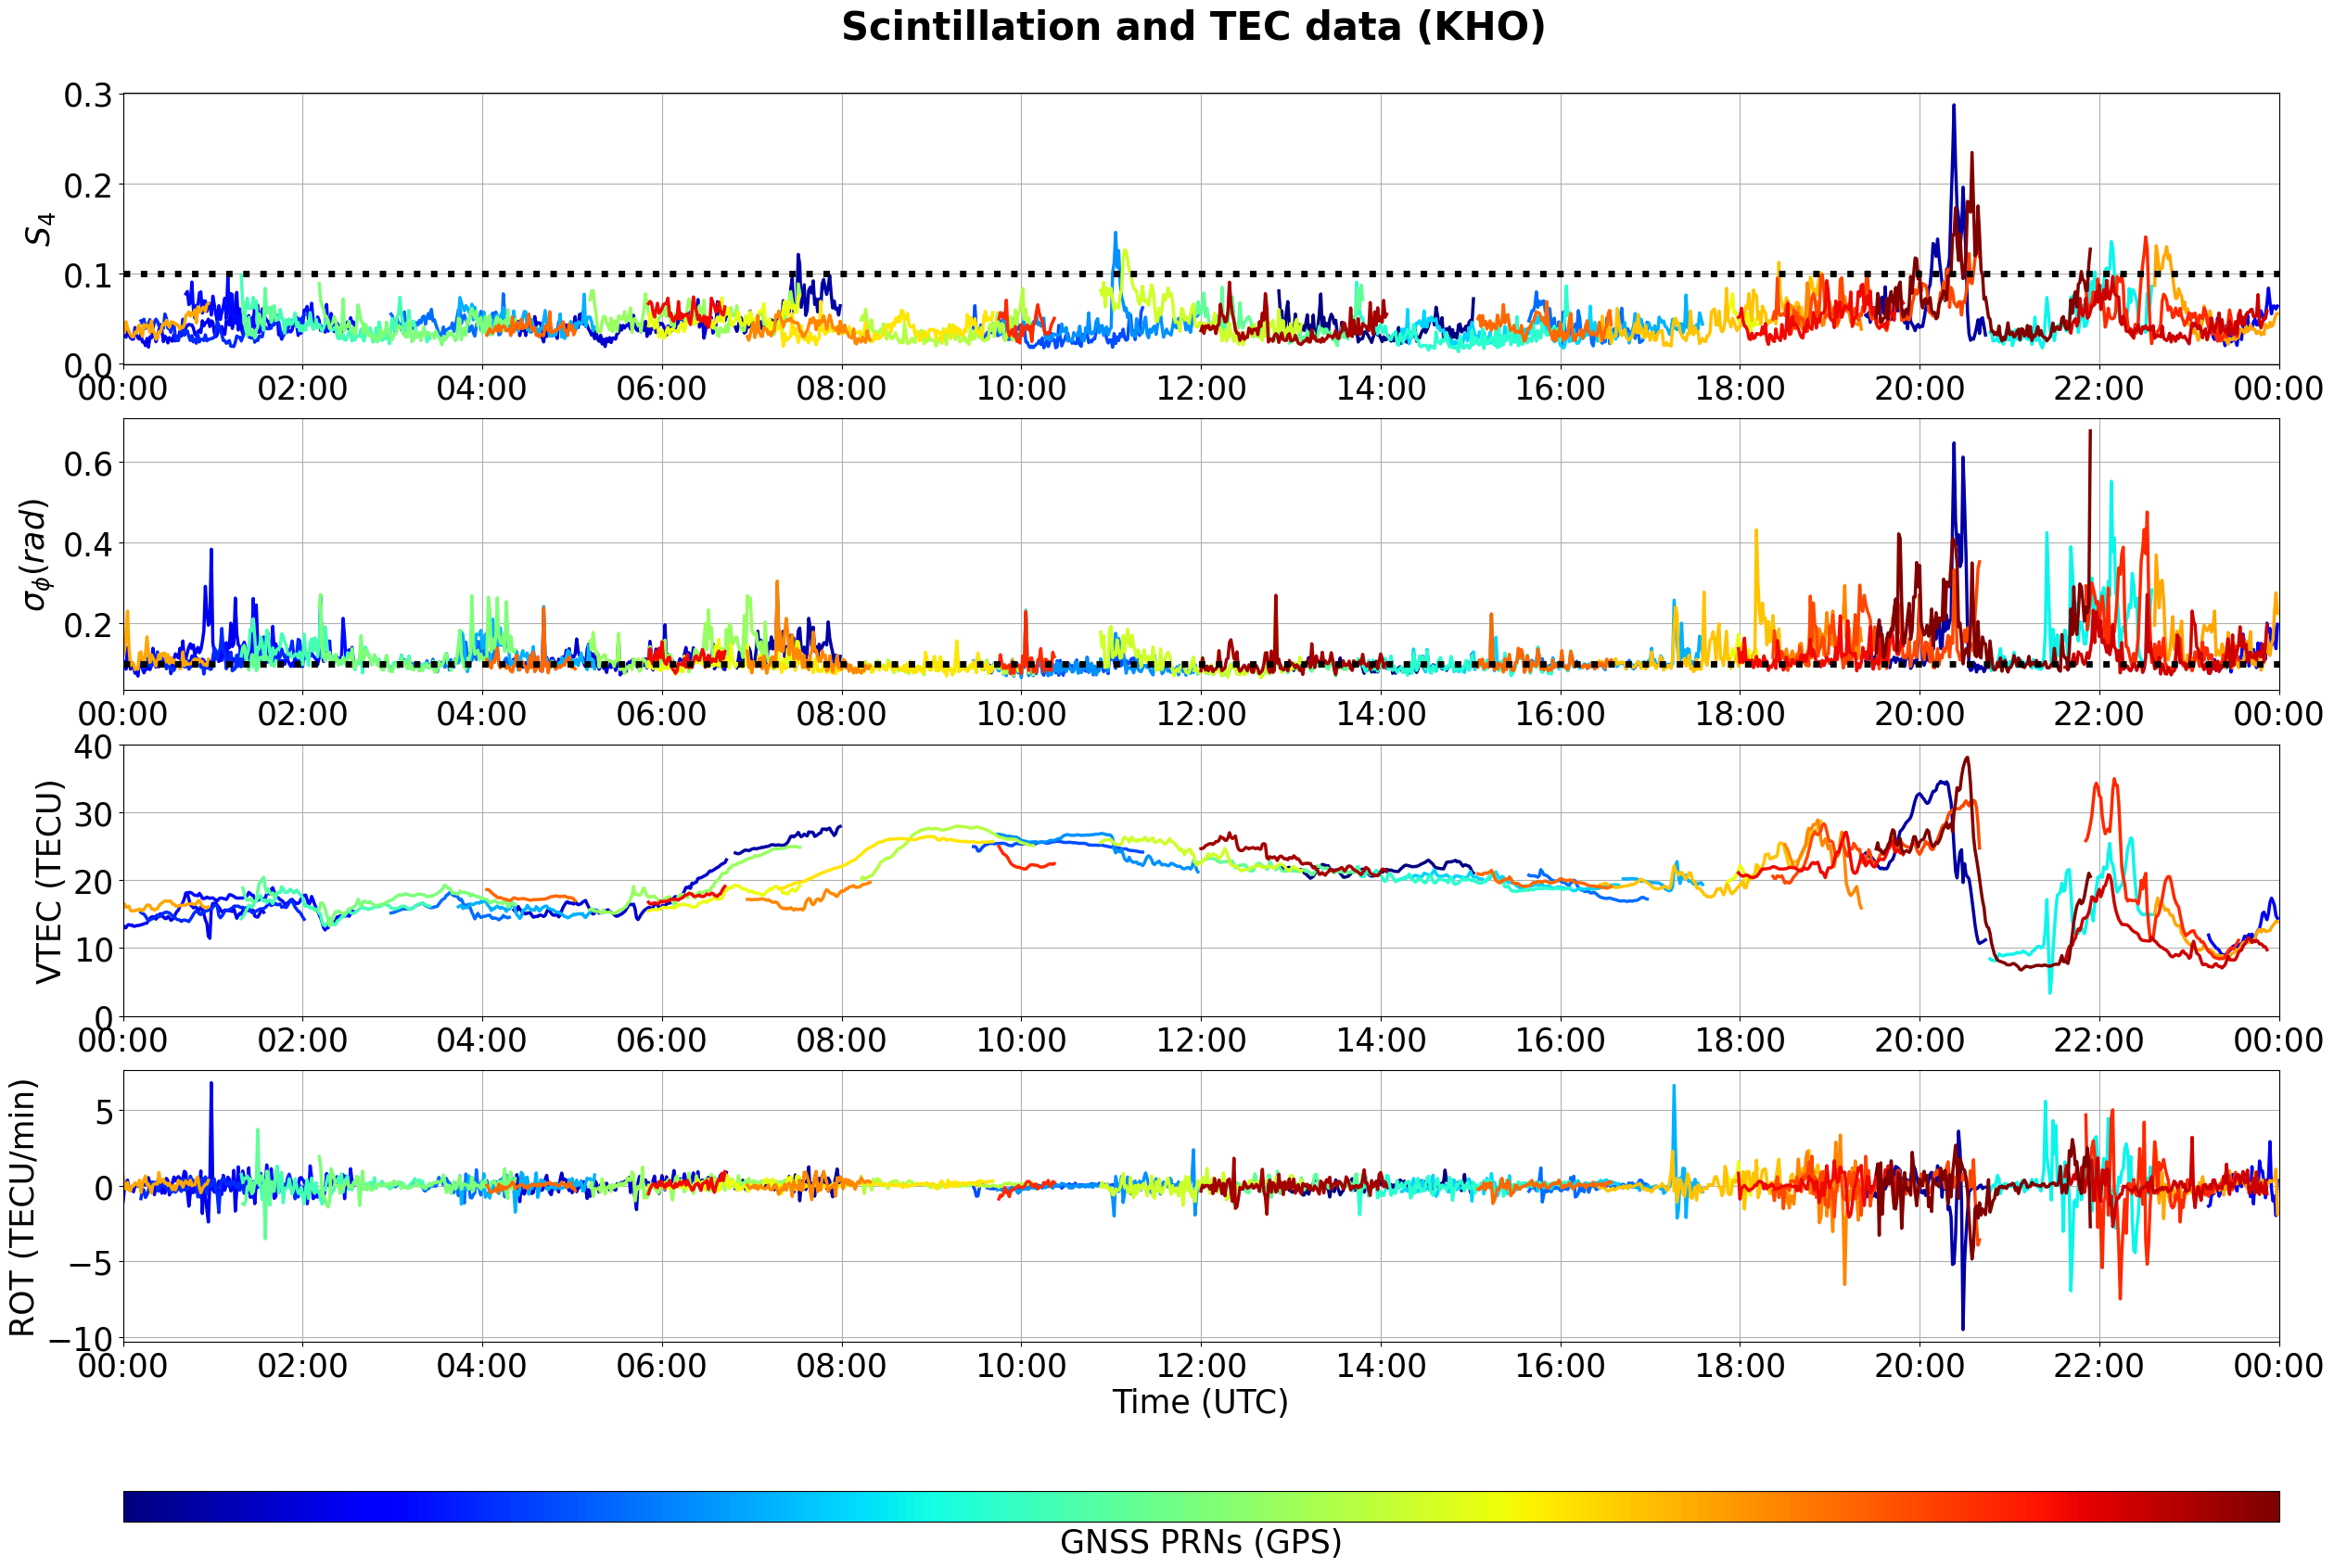

In [16]:

"""
#¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤
# Plotting S4, SPhi, VTEC, ROT vs time 
#¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤
"""
fig = plt.figure(figsize=(30, 25))
plt.rcParams["font.size"] = 25
date_formatter = matplotlib.dates.DateFormatter("%H:%M")
datetime_ticks = matplotlib.dates.HourLocator(interval=2)

gs = fig.add_gridspec(4, 1)
ax0 = fig.add_subplot(gs[0])
ax1 = fig.add_subplot(gs[1])
ax2 = fig.add_subplot(gs[2])
ax3 = fig.add_subplot(gs[3])


kho_prns_unique = np.unique(kho_prns)
prn_names_only = []
for hh in kho_prns_unique:
    prn_names_only.append(" ".join(re.findall("[a-zA-Z]+", hh)))

unique_prn_names_only_temp = np.unique(prn_names_only)
unique_prn_names_only = []
for uu in unique_prn_names_only_temp:
    if uu == "gal":
        unique_prn_names_only.append("Galileo")
    elif uu == "gps":
        unique_prn_names_only.append("GPS")
    else:
        unique_prn_names_only.append("GLONASS")

colors = plt.cm.jet(np.linspace(0, 1, len(kho_prns_unique)))

for pp in range(0, len(kho_prns_unique)):
    req_prn_ind = np.where(kho_prns == kho_prns_unique[pp])[0]

    req_prn_time = kho_time[req_prn_ind]
    req_s4_time = kho_s4[req_prn_ind]
    req_sphi_time = kho_sphi[req_prn_ind]
    req_vtec_time = kho_vtec[req_prn_ind]
    req_rot_time = kho_rot[req_prn_ind]

    req_prn_time_diff = np.diff(req_prn_time) / pd.Timedelta(
        hours=1
    )  # GNSS times already dateshifted to minutes
    gap_hr_ind = np.where(req_prn_time_diff >= 3)[0]
    if len(gap_hr_ind) > 0:
        req_s4_time[gap_hr_ind] = np.nan
        req_sphi_time[gap_hr_ind] = np.nan
        req_vtec_time[gap_hr_ind] = np.nan
        req_rot_time[gap_hr_ind] = np.nan

    """
    #¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤
    # Plots starts here
    #¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤
    """
    ax0.plot(req_prn_time, req_s4_time, color=colors[pp], linewidth=2.5)
    ax1.plot(req_prn_time, req_sphi_time, color=colors[pp], linewidth=2.5)
    ax2.plot(req_prn_time, req_vtec_time, color=colors[pp], linewidth=2.5)
    ax3.plot(req_prn_time, req_rot_time, color=colors[pp], linewidth=2.5)

"""
#¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤
# Plot S4, Sphi = 0.1 line
#¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤
"""
ax0.axhline(y=0.1, color="k", linestyle=":", linewidth=5)
ax1.axhline(y=0.1, color="k", linestyle=":", linewidth=5)

"""
#¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤
# Defining the datetime (Xaxis) limits
#¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤
"""
time_start_scin = pd.Timestamp(int(year_is), int(month_is), int(day_is), 0, 0, 0)
time_end_scin = pd.Timestamp(
    int(year_is), int(month_is), int(day_is), 23, 59, 0
) + dt.timedelta(minutes=1)


ax0.set_ylabel("$S_{4}$")
ax0.set_xlim([time_start_scin, time_end_scin])
ax0.xaxis.set_major_formatter(date_formatter)
ax0.xaxis.set_major_locator(datetime_ticks)
ax0.grid()

ax1.set_ylabel("$\sigma_{\phi} (rad)$")
ax1.set_xlim([time_start_scin, time_end_scin])
ax1.xaxis.set_major_formatter(date_formatter)
ax1.xaxis.set_major_locator(datetime_ticks)
ax1.grid()

ax2.set_ylabel("VTEC (TECU)")
ax2.set_xlim([time_start_scin, time_end_scin])
ax2.xaxis.set_major_formatter(date_formatter)
ax2.xaxis.set_major_locator(datetime_ticks)
ax2.set_ylim([0, 40])
ax2.grid()

ax3.set_ylabel("ROT (TECU/min)")
ax3.set_xlabel("Time (UTC)")
ax3.set_xlim([time_start_scin, time_end_scin])
ax3.xaxis.set_major_formatter(date_formatter)
ax3.xaxis.set_major_locator(datetime_ticks)
ax3.grid()


"""
#¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤
# Add colorbar as legend
#¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤¤
"""
plt_col = plt.scatter(np.nan, np.nan, 10, np.nan, cmap="jet")
cbar = plt.colorbar(
    plt_col,
    ax=[ax0, ax1, ax2, ax3],
    # shrink = 0.935, #with ticks
    shrink=1,  # without ticks
    aspect=70,
    ticks=[],
    location="bottom",
    anchor=(0.43, 1.5),
)
cbar.set_label(
    (
        "GNSS PRNs"
        + " "
        + "("
        + unique_prn_names_only[0]
        + ")"
    )
)

ax0.set_title(f'Scintillation and TEC data ({np.unique(final_dataframe_scin_tec_combined["stn"])[0]}) \n',
             fontsize=30, fontweight='bold')


# Exercise

1. Check how scintillation and TEC activity varies for a geomagnetically quiet day for the same station (i.e., Longyearbyen)
<br>

1. Repeat the above and plot scintillation indices along with VTEC and ROT for a different station (e.g., Ny-Alesund (NYA), Bjornoya (BJN), Hopen (HOP)).
<br>

1. Include other constellations such as Galileo (gal) and Glonass (glo) along with the GPS data.
<br>

1. Points (2), (3) will help reveal the spatio-temporal differences/variations in scintillation and TEC activity. 